In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('GBR_ltmp.csv')
df.head(5)

df.replace({-999 : np.nan}, inplace = True)

df['HC'] = (df
    .groupby(['REEF_NAME', 'TRANSECT_NO'])['HC']
    .transform(lambda x: x.interpolate(method='linear')))


df['HC_1'] = (df
    .groupby(['REEF_NAME', 'TRANSECT_NO'])['HC_1']
    .transform(lambda x: x.interpolate(method='linear')))

df.isna().sum().sort_values(ascending = False)


HERB2            3527
COVER            3352
B                3347
D                3347
DISEASE          3347
COTS             3347
BLEACHING        3347
STORM            3347
S                3347
C                3337
HERB             1380
HC_1              245
DISTURBANCE        30
HC                 15
LAT                 0
A_SECTOR            0
REEF_NAME           0
REEF_ID             0
SHELF               0
TRANSECT_NO         0
REPORT_YEAR         0
SITE_NO             0
SITE_LON            0
LON                 0
SITE_LAT            0
AREA                0
CONNECTEDNESS       0
BENT_CLUST          0
CLUSTER             0
RST                 0
RSTY                0
iZONE               0
sZONE               0
PFp                 0
PFs                 0
PFt                 0
PFsum               0
dtype: int64

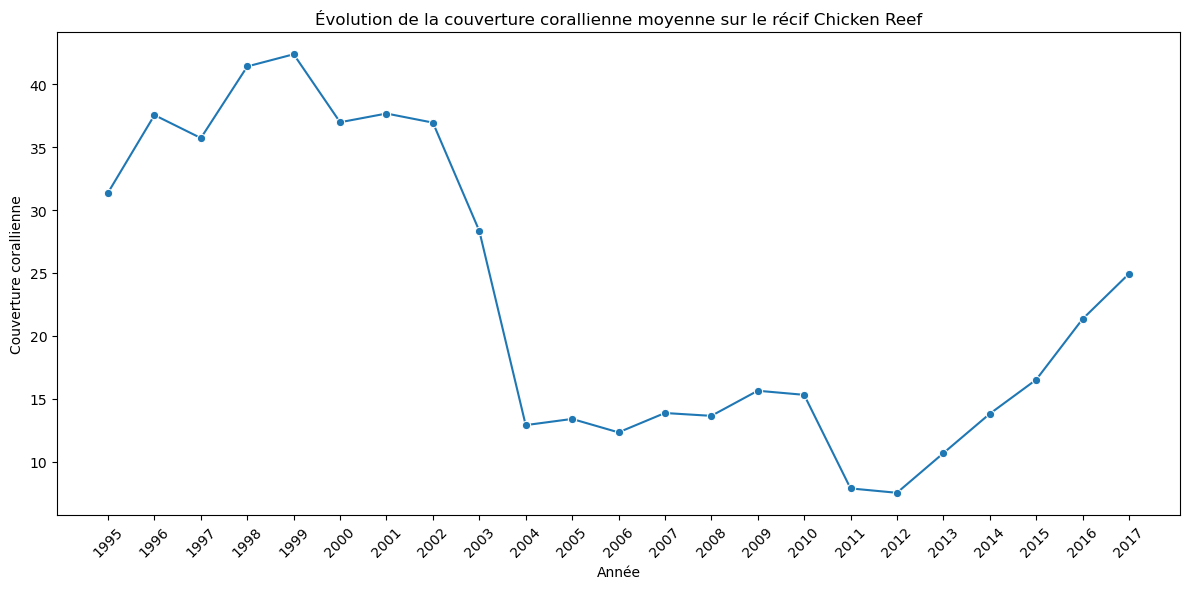

In [33]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

chicken_reef = df.loc[df['REEF_NAME'] == 'CHICKEN REEF'].groupby('REPORT_YEAR')['HC'].mean().reset_index()

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=chicken_reef,
    x='REPORT_YEAR',
    y='HC',
    marker='o'
)

years = sorted(chicken_reef['REPORT_YEAR'].unique())
ax.set_xticks(years)

plt.xticks(rotation=45)  
plt.xlabel("Année")
plt.ylabel("Couverture corallienne")
plt.title("Évolution de la couverture corallienne moyenne sur le récif Chicken Reef")

plt.tight_layout()
plt.show()

In [5]:
ts = chicken_reef.copy()
ts['REPORT_YEAR'] = pd.to_datetime(ts['REPORT_YEAR'], format='%Y')
ts = ts.set_index('REPORT_YEAR')

ts.index = pd.DatetimeIndex(ts.index, freq='YS')  

result = adfuller(ts['HC'])
print("ADF statistic :", result[0])
print("p-value :", result[1])

ADF statistic : -2.1484790449022326
p-value : 0.2254727285636839


In [39]:
ts.head(20)

,HC
REPORT_YEAR,
1995-01-01,31.387333
1996-01-01,37.554000
1997-01-01,35.724667
1998-01-01,41.420667
1999-01-01,42.389333
2000-01-01,36.983333
2001-01-01,37.676000
2002-01-01,36.953333
2003-01-01,28.344000


ADF statistic : -10.509296097919469
p-value : 1.0344895456022529e-18


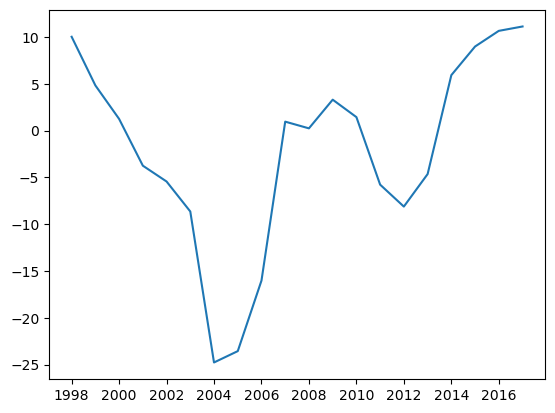

In [43]:
ts_hc = ts['HC'].diff(3).dropna()
result = adfuller(ts_hc)
print("ADF statistic :", result[0])
print("p-value :", result[1])

plt.plot(ts_hc)

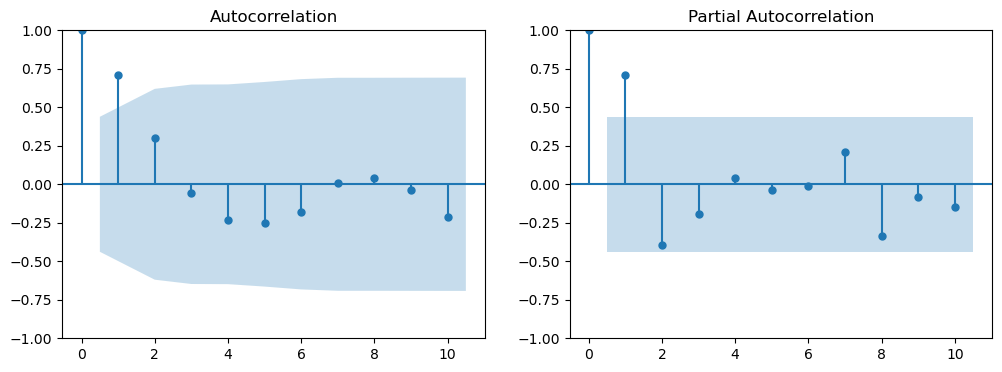

In [44]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

plot_acf(ts_hc, ax=ax[0], lags=10)
plot_pacf(ts_hc, ax=ax[1], lags=10)

plt.show()

In [45]:
model = ARIMA(ts['HC'], order=(1,3,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                     HC   No. Observations:                   23
Model:                 ARIMA(1, 3, 1)   Log Likelihood                 -65.151
Date:                Fri, 13 Mar 2026   AIC                            136.303
Time:                        09:51:10   BIC                            139.290
Sample:                    01-01-1995   HQIC                           136.886
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2679      0.311     -0.861      0.389      -0.878       0.342
ma.L1         -0.9995    100.269     -0.010      0.992    -197.524     195.525
sigma2        33.0865   3315.457      0.010      0.9

C:\Users\lenov\anaconda3\envs\pymc_ofb\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


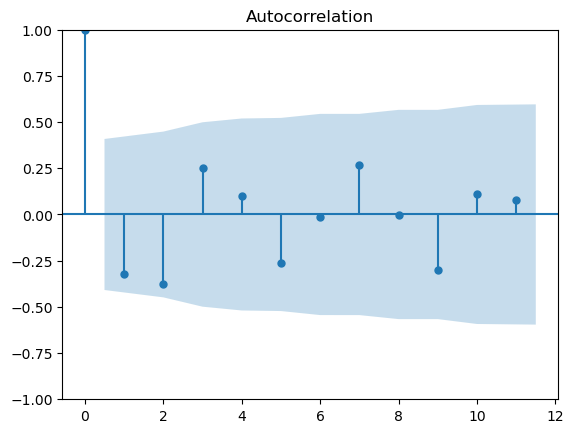

In [46]:
residuals = model_fit.resid

plot_acf(residuals)
plt.show()

In [47]:
forecast = model_fit.forecast(steps=5)

print(forecast)

2018-01-01    28.823109
2019-01-01    32.597127
2020-01-01    36.364027
2021-01-01    40.094706
2022-01-01    43.796961
Freq: YS-JAN, Name: predicted_mean, dtype: float64


In [50]:
pred = model_fit.predict(start='2010-01-01', end='2017-01-01')
pred = model_fit.get_prediction(start='2010-01-01', end='2017-01-01')
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

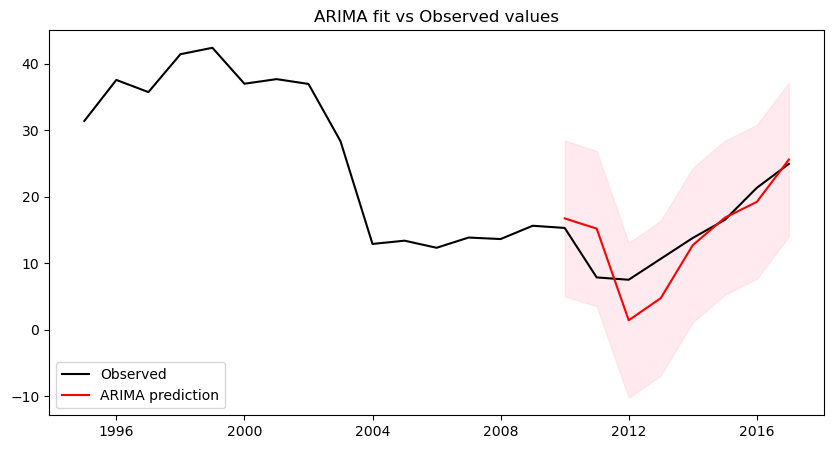

In [51]:
plt.figure(figsize=(10,5))

# série réelle
plt.plot(ts['HC'], label='Observed', color='black')

# prédictions
plt.plot(pred_mean, label='ARIMA prediction', color='red')

# intervalle de confiance
plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:,0],
                 pred_ci.iloc[:,1],
                 color='pink', alpha=0.3)

plt.legend()
plt.title("ARIMA fit vs Observed values")
plt.show()

In [52]:
train = ts['HC'][:'2009']
test = ts['HC']['2010':]

model = ARIMA(train, order=(1,3,1))
fit = model.fit()

forecast = fit.forecast(steps=len(test))

C:\Users\lenov\anaconda3\envs\pymc_ofb\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


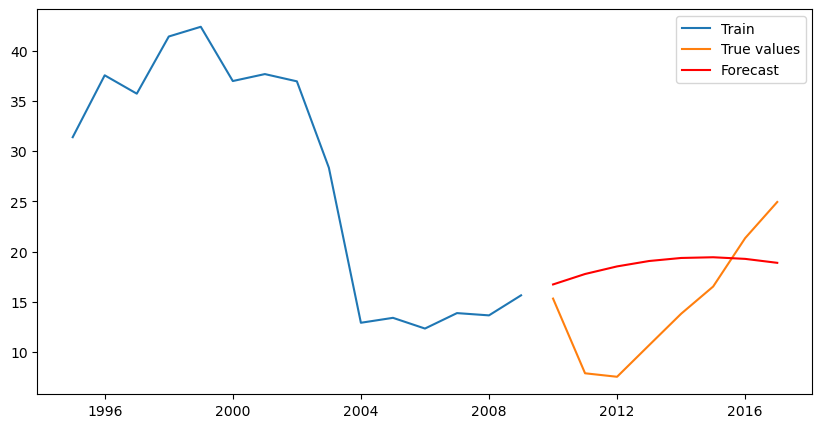

In [53]:
plt.figure(figsize=(10,5))

plt.plot(train, label='Train')
plt.plot(test, label='True values')
plt.plot(forecast, label='Forecast', color='red')

plt.legend()
plt.show()